# CodeAlpha Data Analytics Internship
## Task 3: Data Visualization & Storytelling
**Repository:** `CodeAlpha_ProjectName`  
**Project:** Global Superstore Business & Financial Performance Dashboard  

---

### Visual Objectives
1. **Executive Clarity:** Build a multi-panel visual dashboard summarizing primary financial KPIs and growth trajectory.
2. **Category & Product Insights:** Map revenue against profit margins across all categories to identify "star" items vs profit drains.
3. **Regional & Customer Segmentation:** Compare geographic sales velocity broken down by customer segments (Consumer, Corporate, Home Office).
4. **Discount Destruction Curve:** Visualize the impact of aggressive discounts on profit margins to recommend sound discounting thresholds.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

# Styling setup
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'Segoe UI', 'figure.dpi': 150})

# Load dataset
data_path = os.path.join("data", "superstore_sales_data.csv")
df = pd.read_csv(data_path)
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['YearMonth'] = df['Order_Date'].dt.to_period('M')
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

print(f"Dataset Loaded: {len(df)} transactions")
df.head()


Dataset Loaded: 2500 transactions


,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_Segment,Region,Category,Sub_Category,Quantity,Unit_Price,Discount,Sales,Profit,YearMonth,Profit_Margin
0,CA-2025-100001,2023-04-04,2023-04-08,Second Class,Corporate,Europe,Office Supplies,Appliances,5,277.94,0.05,1320.21,166.40,2023-04,12.604055
1,CA-2025-100002,2023-06-24,2023-06-26,Same Day,Corporate,North America,Office Supplies,Appliances,8,132.50,0.05,1007.00,108.93,2023-06,10.817279
2,CA-2025-100003,2025-12-25,2025-12-27,Same Day,Consumer,Europe,Technology,Copiers & Printers,9,620.08,0.10,5022.65,956.11,2025-12,19.035967
3,CA-2023-100004,2025-10-03,2025-10-04,Standard Class,Consumer,North America,Office Supplies,Storage,2,114.04,0.00,228.08,27.34,2025-10,11.987022
4,CA-2023-100005,2024-08-07,2024-08-09,Standard Class,Corporate,Europe,Technology,Copiers & Printers,1,2164.38,0.10,1947.94,341.00,2024-08,17.505673


---
### 1. Executive Business Performance Dashboard
A multi-panel visualization summarizing key financial health metrics, revenue momentum, regional breakdown, and sub-category profitability.


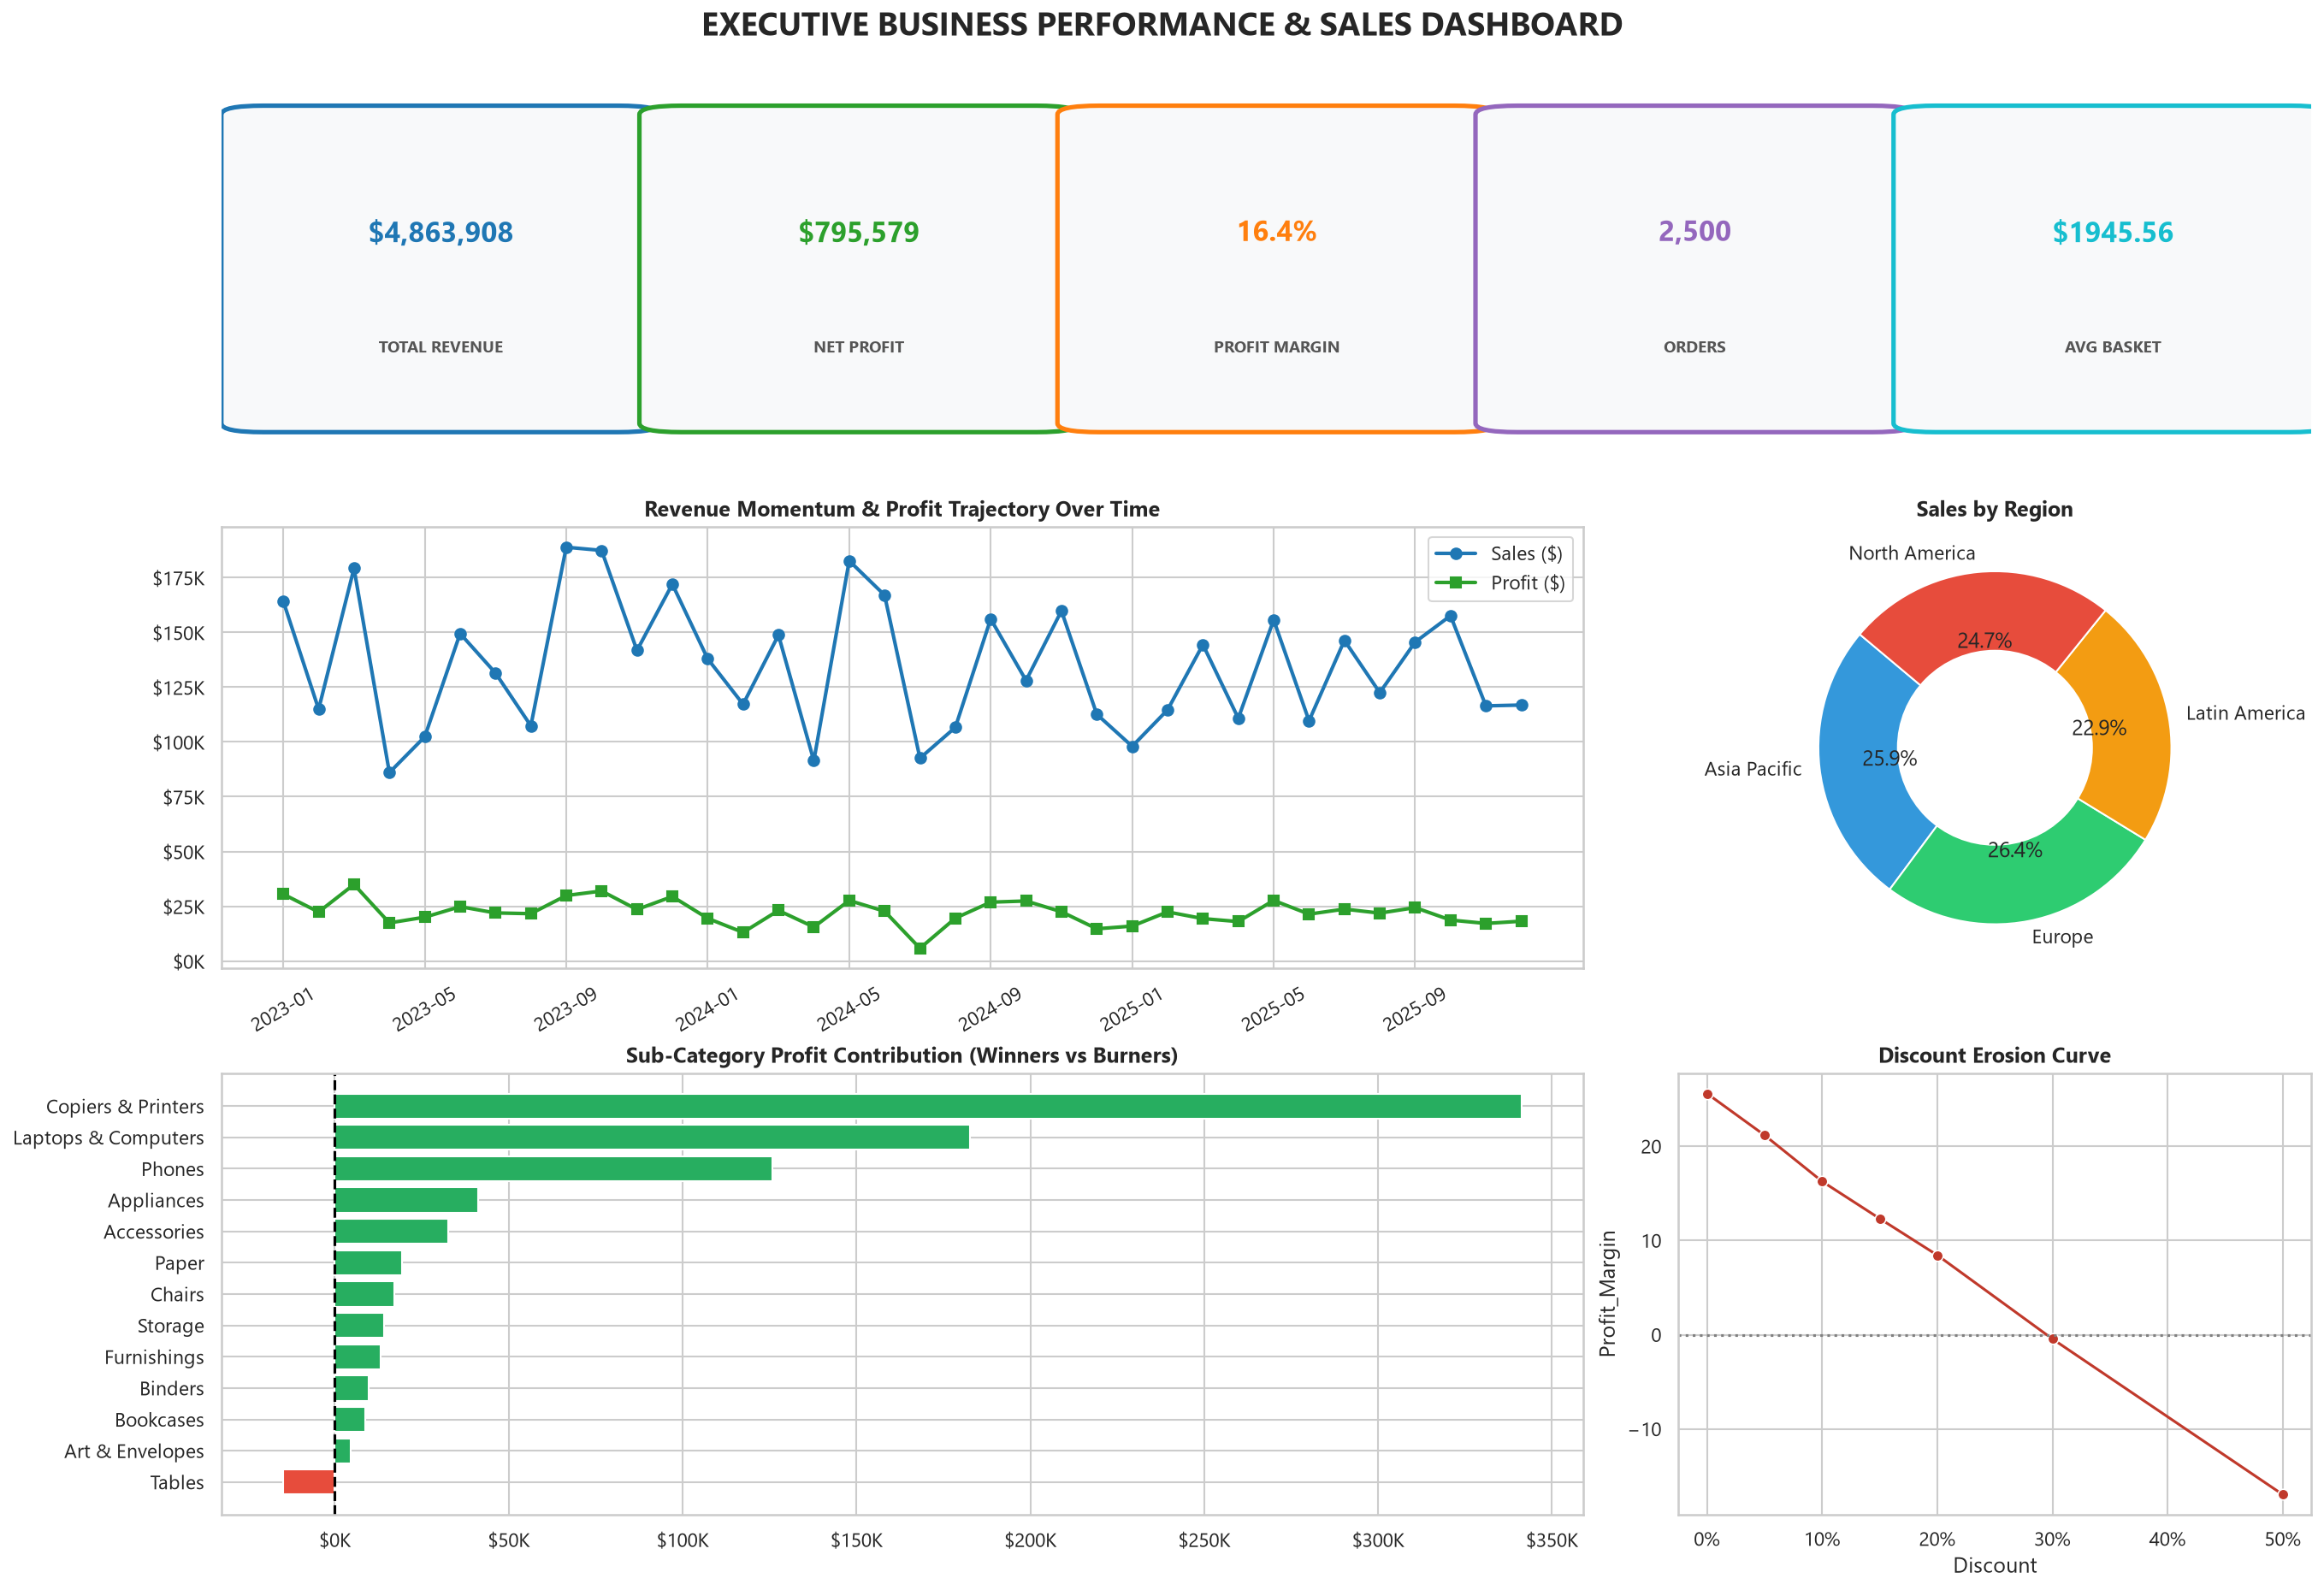

In [2]:
fig = plt.figure(figsize=(18, 12), constrained_layout=True)
gs = fig.add_gridspec(3, 3)

fig.suptitle("EXECUTIVE BUSINESS PERFORMANCE & SALES DASHBOARD", fontsize=18, weight='bold', y=1.02)

# KPI Cards
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')
total_rev = df['Sales'].sum()
total_prof = df['Profit'].sum()
margin = (total_prof / total_rev) * 100
kpis = [
    ("TOTAL REVENUE", f"${total_rev:,.0f}", "#1f77b4"),
    ("NET PROFIT", f"${total_prof:,.0f}", "#2ca02c"),
    ("PROFIT MARGIN", f"{margin:.1f}%", "#ff7f0e"),
    ("ORDERS", f"{len(df):,}", "#9467bd"),
    ("AVG BASKET", f"${df['Sales'].mean():.2f}", "#17becf")
]
for idx, (label, val, col) in enumerate(kpis):
    x = 0.02 + idx * 0.20
    rect = FancyBboxPatch((x, 0.15), 0.17, 0.7, transform=ax_kpi.transAxes,
                          boxstyle="round,pad=0.02", facecolor='#f8f9fa', edgecolor=col, linewidth=2.5)
    ax_kpi.add_patch(rect)
    ax_kpi.text(x + 0.085, 0.58, val, transform=ax_kpi.transAxes, ha='center', va='center', fontsize=16, weight='bold', color=col)
    ax_kpi.text(x + 0.085, 0.32, label, transform=ax_kpi.transAxes, ha='center', va='center', fontsize=9, weight='bold', color='#555555')

# Monthly Trend
ax_trend = fig.add_subplot(gs[1, :2])
monthly = df.groupby('YearMonth').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
monthly['YM_Str'] = monthly['YearMonth'].astype(str)
x_coords = np.arange(len(monthly))
ax_trend.plot(x_coords, monthly['Sales'], marker='o', linewidth=2, color='#1f77b4', label='Sales ($)')
ax_trend.plot(x_coords, monthly['Profit'], marker='s', linewidth=2, color='#2ca02c', label='Profit ($)')
ax_trend.set_xticks(x_coords[::4])
ax_trend.set_xticklabels(monthly['YM_Str'].iloc[::4], rotation=30)
ax_trend.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'${y*1e-3:.0f}K'))
ax_trend.set_title("Revenue Momentum & Profit Trajectory Over Time", weight='bold')
ax_trend.legend()

# Regional Pie
ax_reg = fig.add_subplot(gs[1, 2])
reg_sales = df.groupby('Region')['Sales'].sum()
ax_reg.pie(reg_sales, labels=reg_sales.index, autopct='%1.1f%%', colors=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'], startangle=140)
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
ax_reg.add_artist(centre_circle)
ax_reg.set_title("Sales by Region", weight='bold')

# Sub-category Diverging Bar
ax_sub = fig.add_subplot(gs[2, :2])
sub_p = df.groupby('Sub_Category')['Profit'].sum().sort_values()
b_colors = ['#e74c3c' if v < 0 else '#27ae60' for v in sub_p.values]
ax_sub.barh(sub_p.index, sub_p.values, color=b_colors)
ax_sub.axvline(0, color='black', linestyle='--')
ax_sub.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x*1e-3:.0f}K'))
ax_sub.set_title("Sub-Category Profit Contribution (Winners vs Burners)", weight='bold')

# Discount Curve
ax_d = fig.add_subplot(gs[2, 2])
d_med = df.groupby('Discount')['Profit_Margin'].median().reset_index()
sns.lineplot(data=d_med, x='Discount', y='Profit_Margin', ax=ax_d, marker='o', color='#c0392b')
ax_d.axhline(0, color='gray', linestyle=':')
ax_d.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
ax_d.set_title("Discount Erosion Curve", weight='bold')

plt.show()


---
### 2. Strategic Portfolio Matrix (Sales vs Profit Margin Bubble Plot)
Visualizing each product sub-category in terms of revenue, profit, and units sold.


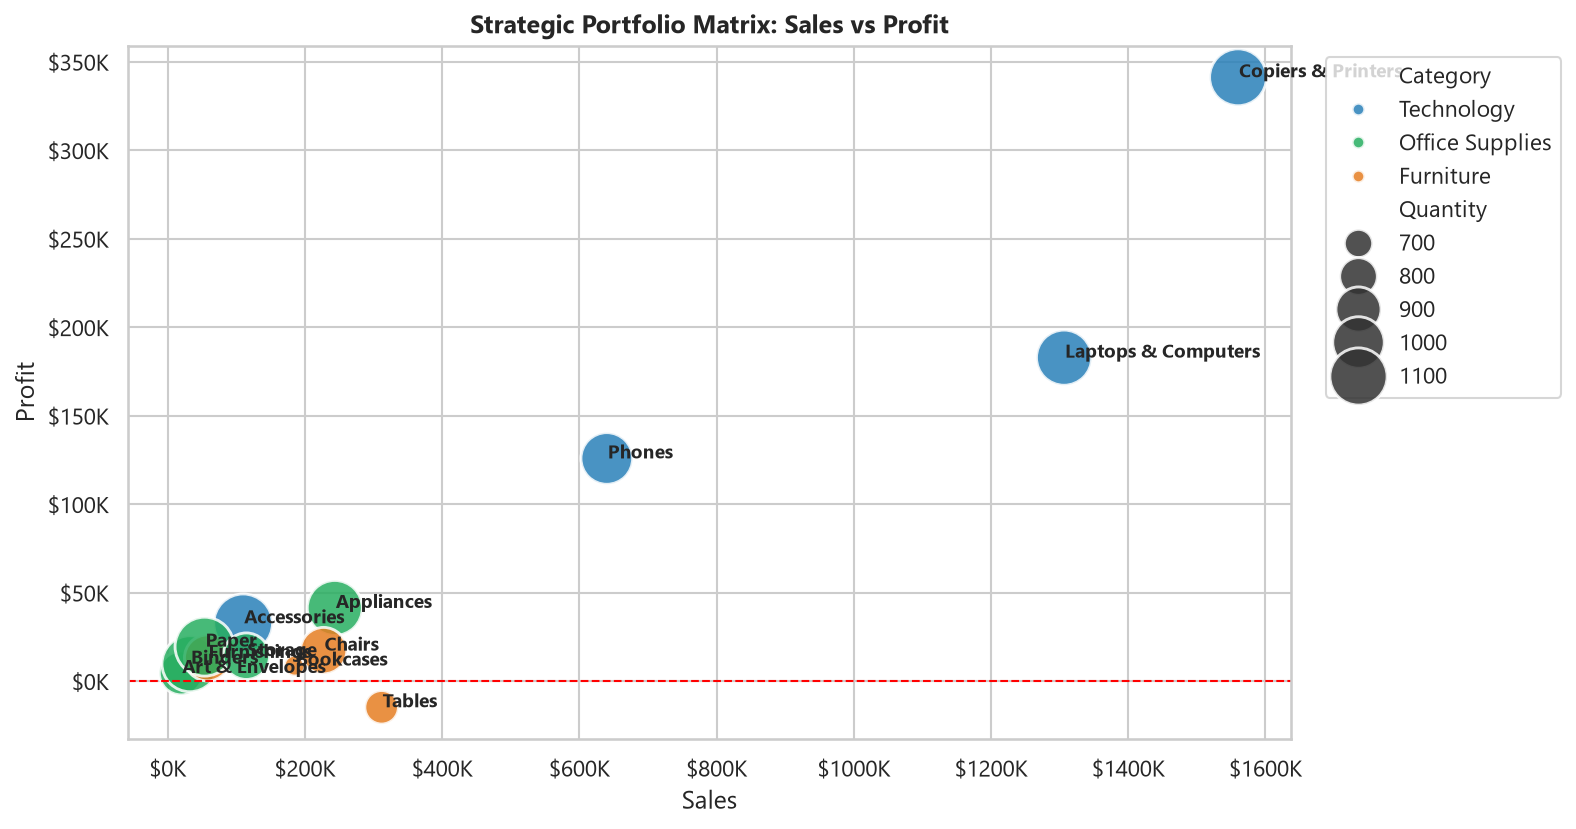

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
cat_sum = df.groupby('Sub_Category').agg({
    'Sales': 'sum', 'Profit': 'sum', 'Quantity': 'sum', 'Category': 'first'
}).reset_index()

sns.scatterplot(
    data=cat_sum, x='Sales', y='Profit', size='Quantity', hue='Category',
    sizes=(100, 800), palette={'Technology': '#2980b9', 'Office Supplies': '#27ae60', 'Furniture': '#e67e22'},
    alpha=0.85, ax=ax
)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
for _, r in cat_sum.iterrows():
    ax.annotate(r['Sub_Category'], (r['Sales'] + 1500, r['Profit']), fontsize=9, weight='bold')

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x*1e-3:.0f}K'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'${y*1e-3:.0f}K'))
ax.set_title("Strategic Portfolio Matrix: Sales vs Profit", weight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


---
### 3. Regional Revenue by Customer Segment
Comparing the performance of Corporate, Consumer, and Home Office clients across all territories.


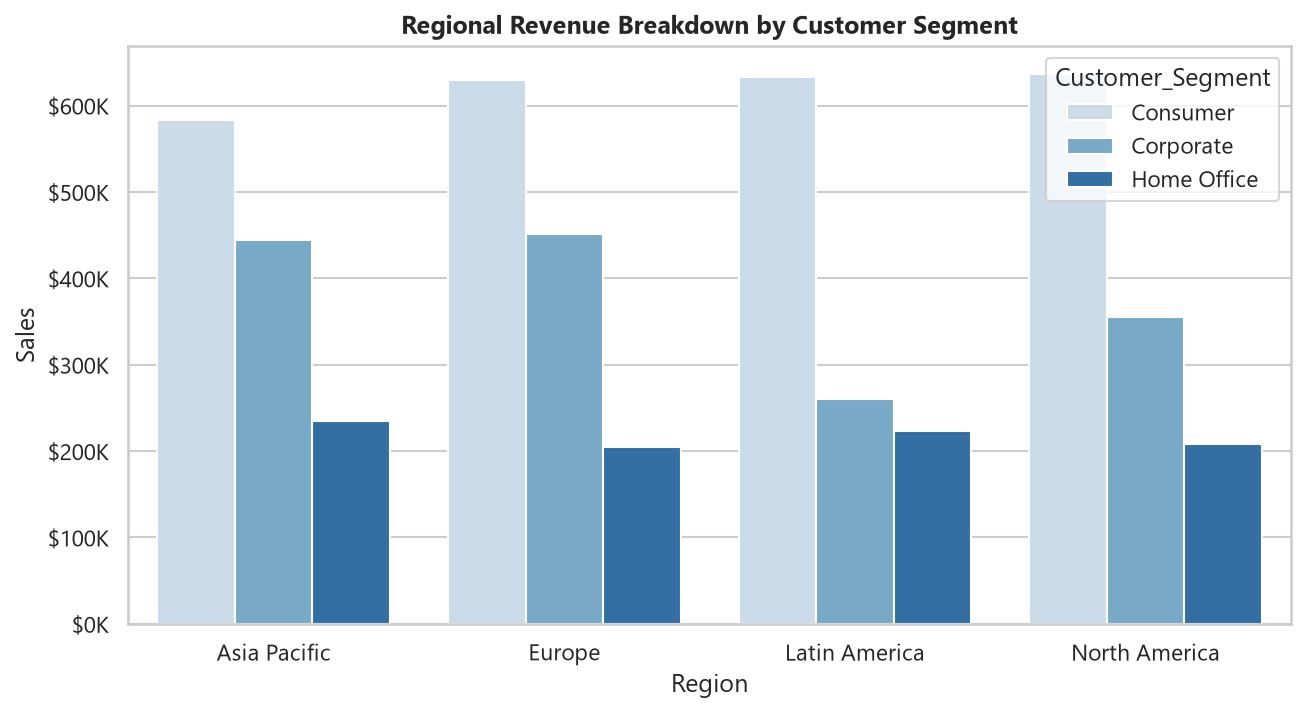

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
seg_df = df.groupby(['Region', 'Customer_Segment'])['Sales'].sum().reset_index()
sns.barplot(data=seg_df, x='Region', y='Sales', hue='Customer_Segment', palette='Blues', ax=ax)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'${y*1e-3:.0f}K'))
ax.set_title("Regional Revenue Breakdown by Customer Segment", weight='bold')
plt.show()


---
### 4. Discounting Risk & Profit Destruction Tiers
Investigating how various discount brackets erode transaction profitability.


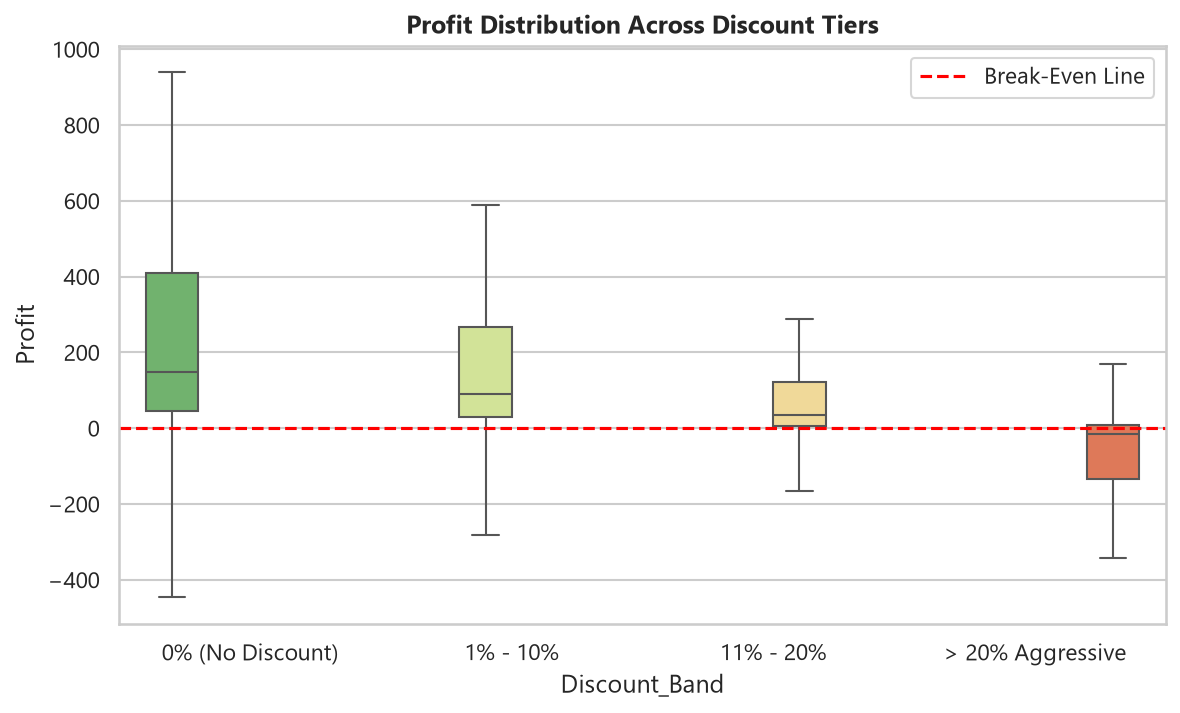

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
df['Discount_Band'] = pd.cut(df['Discount'], bins=[-0.01, 0.0, 0.10, 0.20, 0.50],
                             labels=['0% (No Discount)', '1% - 10%', '11% - 20%', '> 20% Aggressive'])
sns.boxplot(data=df, x='Discount_Band', y='Profit', hue='Discount_Band', palette='RdYlGn_r', ax=ax, showfliers=False, legend=False)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Break-Even Line')
ax.set_title("Profit Distribution Across Discount Tiers", weight='bold')
ax.legend(loc='upper right')
plt.show()


---
### 5. Strategic Recommendations & Data Story
1. **Discount Governance:** Enforce a hard stop at 15% discount; discounts exceeding 20% consistently lead to loss-making orders.
2. **Product Rationalization:** Review the pricing and supply chain costs for "Tables" and "Bookcases", which continually erode net margins.
3. **Core Growth Engine:** Double down on Technology items (Copiers, Phones, Accessories) which produce both strong gross sales and healthy net margins.
